<h1><center>

</center></h1>
<font size="6"><center>
EIE 401
PROCESAMIENTO DIGITAL MULTIMEDIA 
</center></font>


<center><h2>Proyecto 1</h2></center>
<center><h3>Procesamiento digital de señales</h3></center>
<center><h3>Profesor: Jorge Cardenas</h3></center>

<center><h3>Por: Javiera Vega Pino</h3></center>
<center><h5>Pontificia Universidad Catolica de Valparaiso</h5></center>
 

In [2]:
from IPython.display import IFrame, display
filepath = "Proyecto_1_EIE401.pdf"
IFrame(filepath, width=700, height=400)

Debes usar el sitio https://gwosc.org/eventapi/html/GWTC/, donde encuentras todo el catálogo de observaciones con los datos en diferentes formatos. Debes seleccionar una detección para tu estudio y descargar los datos correspondientes (H5 o TXT), lo que posteriormente deberás tratar de manera digital como audio (serie de tiempo).
tip: Te recomiendo tomar la serie de tiempo corta (32 segundos) para facilitar el análisis, y asegurarte de tomar la tasa de muestreo más alta.
tip: Asegúrate de tomar un caso cuyo espectrograma de muestra, indique una señal clara y fuerte para facilitar tu trabajo, de otra forma es posible que no logres aislarla lo suficiente.


## 1. Carga de Datos


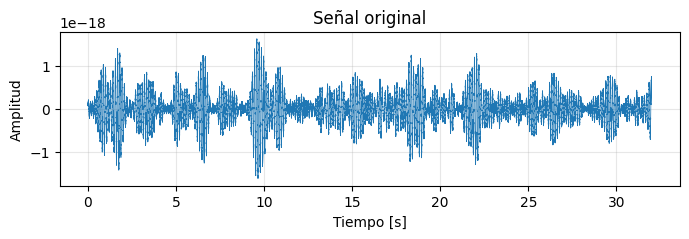

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal.windows import hann, tukey

datos_ligo = 'L-L1_GWOSC_16KHZ_R1-1262879920-32.txt'  #importar los datos
fs = 16384  # tasa de muestreo original de 16 kHz (2^14)

datosL1 = np.loadtxt(datos_ligo) #carga los datos como string
t = np.arange(len(datosL1)) / fs #genera el eje del tiempo

# ploteo de datos originales
plt.figure(figsize=(8, 2))
plt.plot(t, datosL1, lw=0.5)
plt.title("Señal original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Convertir en audio
Es una forma de validar que tenemos un alto componente de ruido en la señal y que el interés es eliminarlo para encontrar una señal candidata.

Te recomiendo hacer una señal de audio de cada uno de las etapas para así validar como va el proceso. Al final deberás obtener un señal con CHIRP o BUMP. Son sonidos que comprueban que tienes una cantidad de potencia que sobre destaca sobre el ruido.

In [4]:
#basado en "9_voice.py"

datos_audio = np.int16(0.9 * datosL1 / np.max(np.abs(datosL1)) * 32767) #primero se pasa a 16 bits y luego se normaliza

wavfile.write("l1_original.wav", fs, datos_audio) #guardar como archivo de audio

## 3. Análisis de Fourier
Al realizar la conversión, queremos ver cuales son las componentes de ruido que más afectan al instrumento y debemos ignorar en el análisis. Eso se ve como "pico" o la apariencia de "peine".
Se debe presenta la densidad espectral de potencia antes y después de la función de Windowing.


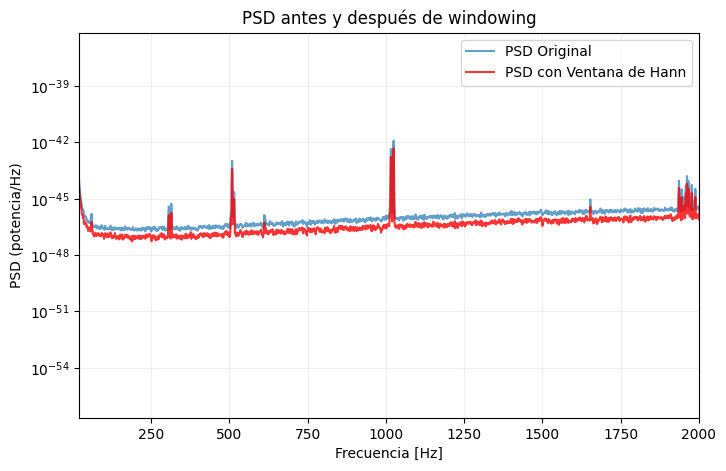

In [5]:

senal_psd, psd_x = signal.welch(datosL1, fs, nperseg=fs) #obtener PSD con método de welch, basado en "11_PSD.py" , se obtiene 1 Hz por punto igualando fs a "nperseg"

ventana_hann = hann(len(datosL1)) # uso de ventana de hann para evitar la fuga espectral suavizando los extremos de la señal. basado en "4_1_windowing.py"
datosL1_hann = datosL1 * ventana_hann
senal_psd_hann, psd_x_hann = signal.welch(datosL1_hann, fs, nperseg=fs) #mismo cáculo de PSD pero ahora la señal está con la ventana aplicada

# plot de PSD antes y después del windowing
plt.figure(figsize=(8, 5))
plt.semilogy(senal_psd, psd_x, label="PSD Original", alpha=0.7) # uso de semilogy porque los valores varían demasiado en ordenes de magnitud
plt.semilogy(senal_psd_hann, psd_x_hann, label="PSD con Ventana de Hann", color='red', alpha=0.8)
plt.title("PSD antes y después de windowing")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD (potencia/Hz)")
plt.xlim(20, 2000) # rango recomendado por mayor sensibilidad en "a guide to LIGO-Virgo..."
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.show()


## 4. Procesamiento 
Debes inferir de tu estudio, cual es el proceso que aplican a la señal y reproducirlo. Es posible que cada estudiante llegue a una solución más o menos diferente, pues no hay un código abierto donde esté el procedimiento completo.


In [6]:
lim = 3 * np.std(datosL1) 
datosL1_limpio = np.clip(datosL1, -lim, lim) #quitar glitches con clipping, basado en lógica de "12_whitening.py"

# Procedimiento de whitening basado en la fórmula de "a guide to LIGO-Virgo..."
N = len(datosL1_limpio)
datos_fft = np.fft.rfft(datosL1_limpio) #pasar señal a dominio de frecuencia
frecuencias_fft = np.fft.rfftfreq(N, d=1.0/fs)

psd_interpolada = np.interp(frecuencias_fft, senal_psd, psd_x) #interpolación de la PSD del punto 3 para hacerla "calzar" con la FFT. logica de normalización de '12_whitening.py'.

white_fft = datos_fft / np.sqrt(psd_interpolada + 1e-20)  # dividir la señal por la raíz de su propia PSD. (+1e-20 evita divisones por 0)

datosL1_white = np.fft.irfft(white_fft, n=N) #devolver al dominio del tiempo para obtener señal blanqueada

filtro = signal.butter(10, [35, 250], btype='bandpass', fs=fs, output='sos') #filtro butterworth pasabanda orden 10 que aisla el rango de 35-250 Hz. basado en "8_audio2.py"

datosL1_filt = signal.sosfiltfilt(filtro, datosL1_white) # se asegura fase cero y que el impacto quede fijo en el tiempo


# Resampling
Para lograr una mejor definición de la señal, se debe hacer un resampleo. Esto tienen consecuencias por eso debe elegirse bien la frecuencia de tal forma que no se introduzca ruido.

evento identificado en t= 22.00 s


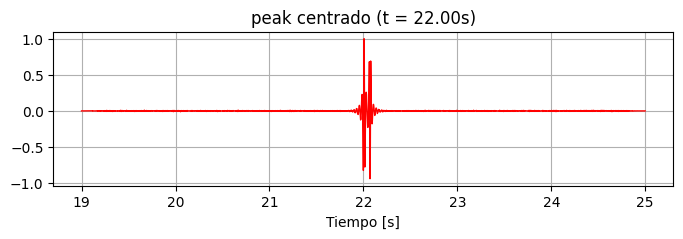

In [7]:
margen = int(10 * fs)  #se crea un margen que ignora los primeros 10 segundos
peak = np.argmax(np.abs(datosL1_filt[margen:-margen])) + margen #identifica el momento exacto del peak

tiempo_peak = t[peak] #encuentra el peak
print(f"evento identificado en t= {tiempo_peak:.2f} s")

ventana = 6.0 #recorte del audio a 6 segundos
muestras_ventana = int(ventana * fs)
inicio = peak - muestras_ventana // 2 #hace que el peak quede en el centro
fin = inicio + muestras_ventana

fragmento_peak = datosL1_filt[inicio:fin] #se corta (slicing) la parte a utilizar de la señal

fs_nueva = 4000  #se suaviza el audio reduciendo la tasa a 4000 Hz. basado de "6_audio.py"

fragmento_peak = fragmento_peak / np.max(np.abs(fragmento_peak)) # extrae los 6 segundos para que el peak quede en el centro. basado de "6_audio1.py"
audio_final = signal.resample(fragmento_peak, int(ventana * fs_nueva))

audio_final *= tukey(len(audio_final), alpha=0.1)#se aplica ventana tukey para evitar clics en el audio. basado de "4_1_windowing.py"

# plot del peak
plt.figure(figsize=(8, 2))
t_final = np.linspace(tiempo_peak - 3, tiempo_peak + 3, len(audio_final))
plt.plot(t_final, audio_final, color='red', lw=1)
plt.title(f"peak centrado (t = {tiempo_peak:.2f}s)")
plt.xlabel("Tiempo [s]")
plt.grid(True)
plt.show()

audio_final_int16 = np.int16(audio_final * 32767) #se usa el nuevo audio y se convierte a 16 bits. basado de "9_voice.py"
wavfile.write("l1_filtrado.wav", fs_nueva, audio_final_int16)

# Espectrograma
Se crea el espectograma que permite interpretar el chirp de la señal de manera visual en un plot.

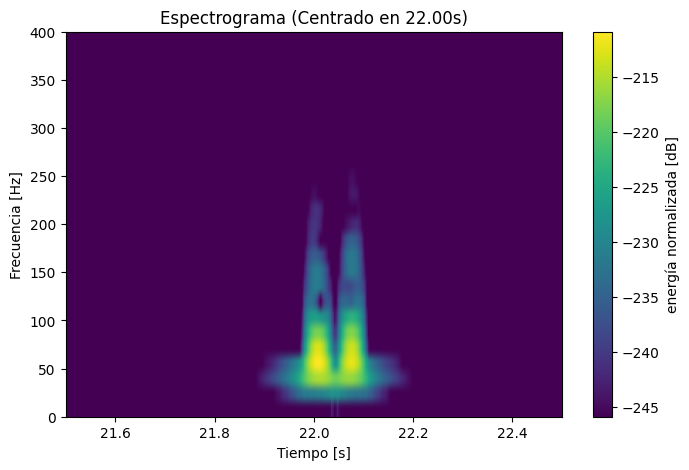

In [8]:
rango = 0.5  #ventana
inicio_peak = max(0, peak - int(rango * fs)) #se centra en el peak detectado
fin_peak = min(len(datosL1_filt), peak + int(rango * fs))

max_peak = datosL1_filt[inicio_peak:fin_peak] #maximiza el peak

plt.figure(figsize=(8, 5))

spectrum, freqs, t_spec, im = plt.specgram(    #usa en NFFT de 1024 para mejorar la resolucion en frecuencia y noverlap 98% para suavizar los colores. basado en "12_whitening.py"
    max_peak, 
    NFFT=1024, 
    Fs=fs, 
    noverlap=980, 
    cmap='viridis'
)

max_dB = np.max(10 * np.log10(spectrum))  #se obtiene la intensidad máxima del peak en dB. basado en la normalización de "12_whitening.py"

v_min = max_dB - 35  # fondo azul 35 dB por debajo del máximo

v_max = max_dB  #peak amarillo nivel máximo de la señal

im.set_clim(v_min, v_max) #ajusta los límites de color

im.set_extent([tiempo_peak - rango, tiempo_peak + rango, 0, fs/2]) #se modifica "extent" para que se vea el tiempo real del peak en el plot

#plot espectograma
plt.title(f"Espectrograma (Centrado en {tiempo_peak:.2f}s)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.ylim(0, 400) 
plt.colorbar(label="energía normalizada [dB]")
plt.grid(False) 
plt.show()

# Referencias
* [Catálogo de eventos GWOSC](https://gwosc.org/eventapi/html/GWTC/)
* [A guide to LIGO-Virgo detector noise and extraction of transient gravitational-wave signals](https://iopscience.iop.org/article/10.1088/1361-6382/ab685e)
* [Searching for gravitational waves produced by cosmic strings in LIGO-Virgo data](https://theses.hal.science/tel-02878783v1/file/82248_BELAHCENE_2019_archivage.pdf)
* [On the Signal Processing Operations in LIGO signals](https://arxiv.org/pdf/1711.07421)
* [numpy.clip](https://numpy.org/doc/2.4/reference/generated/numpy.clip.html)
* [set_clim](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.clim.html)